# Notebook 06 - Mini Clasificador de Sentimientos

## Objetivo
Entrenar un clasificador binario (positivo/negativo) con un dataset de ~100 ejemplos aplicando limpieza, tokenizacion, padding, entrenamiento y prediccion.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

df = pd.read_csv("../datasets/opiniones_clientes.csv")
print("Shape del dataset:", df.shape)
print(df.head())
print("\nDistribucion de clases:")
print(df['sentimiento'].value_counts())

Shape del dataset: (100, 2)
                                               texto sentimiento
0  Excelente servicio y atencion del equipo (caso...    positivo
1  Recibi mi pedido rapido y en perfecto estado (...    positivo
2  La calidad del producto supero mis expectativa...    positivo
3  Muy buena experiencia de compra online (caso p...    positivo
4  El soporte tecnico resolvio mi problema ensegu...    positivo

Distribucion de clases:
sentimiento
positivo    50
negativo    50
Name: count, dtype: int64


## 1) Limpieza de texto
Aplicamos una limpieza conservadora para no perder semantica importante.

In [2]:
def limpiar_texto(texto: str) -> str:
    texto = texto.lower()  # Uniformidad
    texto = re.sub(r"[^a-zÃ¡Ã©Ã­Ã³ÃºÃ±\s]", " ", texto)  # Quita ruido no alfabetico
    texto = re.sub(r"\s+", " ", texto).strip()  # Normaliza espacios
    return texto

df['texto_limpio'] = df['texto'].astype(str).apply(limpiar_texto)
print(df[['texto', 'texto_limpio']].head(5).to_string(index=False))

                                                              texto                                                    texto_limpio
         Excelente servicio y atencion del equipo (caso positivo 1)          excelente servicio y atencion del equipo caso positivo
     Recibi mi pedido rapido y en perfecto estado (caso positivo 2)      recibi mi pedido rapido y en perfecto estado caso positivo
  La calidad del producto supero mis expectativas (caso positivo 3)   la calidad del producto supero mis expectativas caso positivo
           Muy buena experiencia de compra online (caso positivo 4)            muy buena experiencia de compra online caso positivo
El soporte tecnico resolvio mi problema enseguida (caso positivo 5) el soporte tecnico resolvio mi problema enseguida caso positivo


## 2) Tokenizacion y secuencias
Construimos vocabulario con `Tokenizer` y convertimos texto en listas de enteros.

In [3]:
max_vocab = 1200
tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(df['texto_limpio'])
secuencias = tokenizer.texts_to_sequences(df['texto_limpio'])

print("Tamano de vocabulario aprendido:", len(tokenizer.word_index))
print("Ejemplo de secuencia:", secuencias[0])

Tamano de vocabulario aprendido: 84
Ejemplo de secuencia: [28, 13, 5, 29, 8, 30, 2, 3]


## 3) Padding
Ajustamos todas las secuencias a una longitud fija para poder formar batches.

In [4]:
max_len = 12
X = pad_sequences(secuencias, maxlen=max_len, padding="post", truncating="post")
y = (df['sentimiento'] == 'positivo').astype(int).values

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (100, 12)
Shape y: (100,)


## 4) Division entrenamiento/prueba
Separamos datos para estimar generalizacion.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (80, 12) (80,)
Test: (20, 12) (20,)


## 5) Construccion del modelo
Arquitectura: Embedding -> GlobalAveragePooling1D -> Dense(ReLU) -> Dense(Sigmoid).

In [6]:
vocab_size = min(len(tokenizer.word_index) + 1, max_vocab)
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    GlobalAveragePooling1D(),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 12, 32)            2720      
                                                                 
 global_average_pooling1d (G  (None, 32)               0         
 lobalAveragePooling1D)                                          
                                                                 
 dense (Dense)               (None, 16)                528       
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 3,265
Trainable params: 3,265
Non-trainable params: 0
_________________________________________________________________


## 6) Entrenamiento y metricas
Entrenamos pocas epocas para mantener el ejemplo rapido.

In [7]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=8,
    batch_size=16,
    verbose=0
)

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy test: {acc:.4f}")
print(f"Loss test: {loss:.4f}")

Accuracy test: 1.0000
Loss test: 0.6267


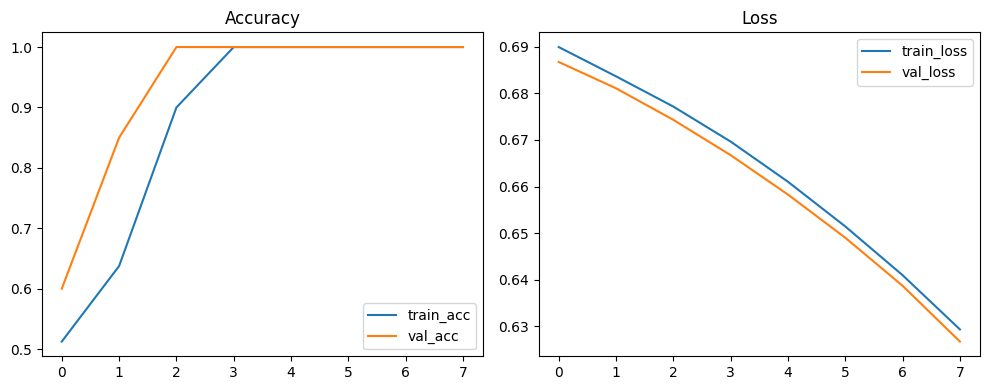

In [8]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 7) Predicciones de ejemplo
Mostramos predicciones sobre textos del conjunto de prueba.

In [9]:
probs = model.predict(X_test[:8], verbose=0).ravel()
for i, p in enumerate(probs):
    pred = 'positivo' if p >= 0.5 else 'negativo'
    real = 'positivo' if y_test[i] == 1 else 'negativo'
    print(f"Ejemplo {i+1}: pred={pred:8s} | real={real:8s} | prob={p:.3f}")

Ejemplo 1: pred=positivo | real=positivo | prob=0.518
Ejemplo 2: pred=positivo | real=positivo | prob=0.518
Ejemplo 3: pred=positivo | real=positivo | prob=0.522
Ejemplo 4: pred=positivo | real=positivo | prob=0.532
Ejemplo 5: pred=negativo | real=negativo | prob=0.445
Ejemplo 6: pred=negativo | real=negativo | prob=0.473
Ejemplo 7: pred=negativo | real=negativo | prob=0.453
Ejemplo 8: pred=positivo | real=positivo | prob=0.525


## 8) Prediccion de frase ingresada por el estudiante
Puedes escribir una frase y el modelo estimara el sentimiento.

In [10]:
def predecir_sentimiento(frase: str) -> tuple[str, float]:
    limpia = limpiar_texto(frase)
    seq = tokenizer.texts_to_sequences([limpia])
    x_in = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    prob = float(model.predict(x_in, verbose=0)[0][0])
    etiqueta = 'positivo' if prob >= 0.5 else 'negativo'
    return etiqueta, prob

try:
    frase_usuario = input('Escribe una frase para clasificar sentimiento: ')
    if not frase_usuario.strip():
        frase_usuario = 'el servicio fue rapido y excelente'
except EOFError:
    frase_usuario = 'el servicio fue rapido y excelente'

etiqueta, prob = predecir_sentimiento(frase_usuario)
print(f"Frase: {frase_usuario}")
print(f"Prediccion: {etiqueta} (prob={prob:.3f})")

Frase: Me siento triste
Prediccion: negativo (prob=0.462)


## Preguntas de reflexion
1. Que errores comete mas el modelo: falsos positivos o falsos negativos?
2. Como cambia el resultado al modificar `max_len` o `embedding_dim`?
3. Que limitaciones observas al entrenar con solo ~100 ejemplos?